# **The objectives of the lab**

The purpose of this lab is to reproduce tables 3.1 and 3.2 from  the third chapter of the book   "Elements of Statistical Learning" from Hastie, Tibshirani and Friedman, as  shown bellow. The objective of the homework is to reproduce partially   table 3.3.

Complete the following code to make it work


https://zoom.us/j/9888668613

In [1]:
import numpy as np
n = 12
np.random.randint(1,n+1,size=1)

array([8])

 1. Prepare the data :

 Raw data is available on line, download it from  moodle ({\tt Data.txt} file) or from the web at
https://web.stanford.edu/~hastie/ElemStatLearn/datasets/prostate.data

In [3]:
import pandas as pd

url_data = "https://web.stanford.edu/~hastie/ElemStatLearn/datasets/prostate.data"
df = pd.read_csv(url_data, delimiter='\t')

In [4]:
df.head(n=10)

,Unnamed: 0,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,lpsa,train
0,1,-0.579818,2.769459,50,-1.386294,0,-1.386294,6,0,-0.430783,T
1,2,-0.994252,3.319626,58,-1.386294,0,-1.386294,6,0,-0.162519,T
2,3,-0.510826,2.691243,74,-1.386294,0,-1.386294,7,20,-0.162519,T
3,4,-1.203973,3.282789,58,-1.386294,0,-1.386294,6,0,-0.162519,T
4,5,0.751416,3.432373,62,-1.386294,0,-1.386294,6,0,0.371564,T
5,6,-1.049822,3.228826,50,-1.386294,0,-1.386294,6,0,0.765468,T
6,7,0.737164,3.473518,64,0.615186,0,-1.386294,6,0,0.765468,F
7,8,0.693147,3.539509,58,1.536867,0,-1.386294,6,0,0.854415,T
8,9,-0.776529,3.539509,47,-1.386294,0,-1.386294,6,0,1.047319,F
9,10,0.223144,3.244544,63,-1.386294,0,-1.386294,6,0,1.047319,F


Extract and normalize the explicative variables

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    <b>1.c) Is it wise to normalize these data?</b>
    The data needs to be normalized because the numerical features have very different scales. This means that the coefficients for each variable (In Ax = b equation) can vary a lot in greatness as well, wich might be more difficulties to define the best parameters.
  </p>
</div>

In [5]:
variables = df.columns[1:9]
df[variables] = df[variables].apply(lambda x: (x - x.mean()) / x.std())

In [6]:
# Get the training and test sets
Y_train = df.loc[df["train"]=="T", 'lpsa'].to_numpy()
X_train = df.loc[df["train"]=="T", variables].to_numpy()
print("Training set : n = {} samples and p = {} dimensions".format(X_train.shape[0], X_train.shape[1]))

Y_test = df.loc[df["train"]=="F", 'lpsa'].to_numpy()
X_test = df.loc[df["train"]=="F", variables].to_numpy()
print("Test set : n = {} samples and p = {} dimensions".format(X_test.shape[0], X_test.shape[1]))

Training set : n = 67 samples and p = 8 dimensions
Test set : n = 30 samples and p = 8 dimensions


<Axes: >

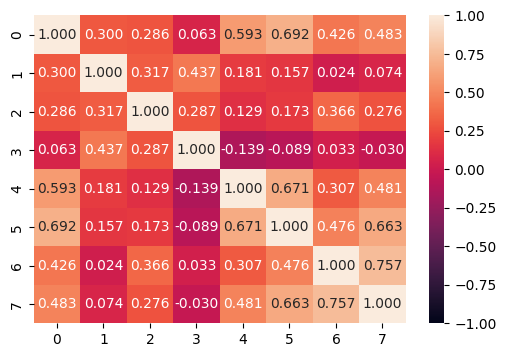

In [7]:
# Correlation matrix

import numpy as np

Xn = (X_train - X_train.mean(axis=0))/X_train.std(axis=0)
n, p = Xn.shape
C = Xn.T@Xn/n
# or C = np.corrcoef(X_train.T)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(C, annot=True, fmt=".3f", vmin=-1)

In [8]:
X = np.concatenate( (np.ones((X_train.shape[0],1)), X_train), axis=1)
b_ls = np.linalg.solve(X.T@X, X.T@Y_train)

In [9]:
Y_train_n = Y_train - Y_train.mean()
beta2 = np.linalg.solve(X_train.T@X_train, X_train.T@Y_train_n)
beta_0 =  Y_train.mean()
print(beta_0)
print(beta2)
print(b_ls)

2.4523450850746267
[ 0.67912148  0.26265894 -0.1393084   0.20963901  0.30568635 -0.29004888
 -0.02432796  0.27027469]
[ 2.46493292  0.67952814  0.26305307 -0.14146483  0.21014656  0.3052006
 -0.28849277 -0.02130504  0.26695576]


$$
\hat{\beta}^{\mbox{ls}} = (X^\top X)^{-1} X^\top y
$$
$$
(X^\top X) \hat{\beta}^{\mbox{ls}} = X^\top y
$$
$$A x = b$$


In [10]:
n, p = X.shape

y_hat = X@b_ls
err = Y_train - y_hat
sigma_square = err.T@err/(n-p)
vector_v = np.diag(np.linalg.inv(X.T@X))
std_error_coef = np.sqrt(sigma_square * vector_v)

z_score = b_ls/(std_error_coef)

In [11]:
from scipy.stats import t

dof = n-p
p_val = 2*(1-t.cdf(np.abs(z_score),dof))

In [12]:
dash = '-' * 60
print(dash)
print("{:<11s}{:<1s}{:<13s}{:<10s}{:<10s}".format("Term",  "Coefficient", "   Std. error","    Z score","       p val"))
print(dash)
for k in range(variables.shape[0]+1):
    if k==0:
        print("{:<10s}{:>12.2f}{:>12.2f}{:>12.2f}{:>12.2f}".format("Intercept", b_ls[k], std_error_coef[k], z_score[k], p_val[k]))
    else:
        print("{:<10s}{:>12.2f}{:>12.2f}{:>12.2f}{:>12.2f}".format(variables[k-1], b_ls[k], std_error_coef[k], z_score[k], p_val[k]))
print(dash)

------------------------------------------------------------
Term       Coefficient   Std. error    Z score       p val
------------------------------------------------------------
Intercept         2.46        0.09       27.60        0.00
lcavol            0.68        0.13        5.37        0.00
lweight           0.26        0.10        2.75        0.01
age              -0.14        0.10       -1.40        0.17
lbph              0.21        0.10        2.06        0.04
svi               0.31        0.12        2.47        0.02
lcp              -0.29        0.15       -1.87        0.07
gleason          -0.02        0.15       -0.15        0.88
pgg45             0.27        0.15        1.74        0.09
------------------------------------------------------------


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    <b>4. Propose a prompt to get the same result with any AI. Explain the AI you have chosen, the way you work on your prompt and don’t spend more than 15 minutes in trying</b>
    Write a python code that: (1) Reads the data from "https://web.stanford.edu/~hastie/ElemStatLearn/datasets/prostate.data"; (2) Normalize the data; (3) Divide it into train and test, and X and Y (features and target); (4) Normalize once again; (5) Plot a correlation matrix of the features; (6) Compute the coefficients and intersept using a linear regression model (7) Compute the prediction error, standard error for each variable and z score; (8) Print a table with all those values for each feature and the intersept.
"
  </p>
</div>

<img src = "https://i.stack.imgur.com/epSz4.png">

On peut obtenir le même résultat par la méthode de prétraitement pour le biais (l'intercept) du calcul.
On a

$$
J(\beta_0,\beta) = \sum_{i=1}^N \left[y_i - \beta_0 -  \sum_{j=1}^p  x_{ij}  \beta_j \right]^2 +   \lambda \sum_{j=1}^p |\beta_j|^q
$$

soit
$$
J(\beta_0,\beta) = \sum_{i=1}^N \left[y_i - \beta_0 -  \sum_{j=1}^p  (x_{ij} - \bar{x}_j + \bar{x}_j)  \beta_j \right]^2 +   \lambda \sum_{j=1}^p |\beta_j|^q
$$
$$
J(\beta_0,\beta) = \sum_{i=1}^N \left[y_i - \beta_0 - \sum_{j=1}^p  \bar{x}_j \beta_j -  \sum_{j=1}^p  (x_{ij} - \bar{x}_j)  \beta_j \right]^2 +   \lambda \sum_{j=1}^p |\beta_j|^q
$$
en posant
$$
\beta_0^c = \beta_0 + \sum_{j=1}^p  \bar{x}_j \beta_j
$$
et
$$
\beta_j^c = \beta_j
$$
on a
$$
 J(\beta_0,\beta) = J(\beta_0^c,\beta^c) =  \sum_{i=1}^N  \left[ y_i - \beta_0^c -  \sum_{j=1}^p  (x_{ij} - \bar{x}_j)  \beta^c \right]^2  +   \lambda \sum_{j=1}^p |\beta_j^c|^q
$$
Maintenant je calcule la dérivée du cout $J(\beta_0^c,\beta^c)$ par rapport à $\beta_0^c$
$$
\frac{d J(\beta_0^c,\beta^c)}{d \beta_0^c} = -2 \sum_{i=1}^N  \left[ y_i - \beta_0^c -  \sum_{j=1}^p  (x_{ij} - \bar{x}_j)  \beta^c \right]
$$
$$
\frac{d J(\beta_0^c,\beta^c)}{d \beta_0^c} = 0
\Leftrightarrow
\beta_0^c = \frac{1}{n} \sum_{i=1}^N y_i = \bar{y}
$$
on pose maintenant $\tilde{y_i} = y_i - \bar{y}$ et $\tilde{x_{ij}} = x_{ij} - \bar{x_j}$
Le problème se réécrit SANS INTERCEPT
$$
J(\beta_0^c,\beta^c) =  \sum_{i=1}^N  \left[ \tilde{y_i} -  \sum_{j=1}^p  \tilde{x_{ij}}  \beta^c \right]^2  +   \lambda \sum_{j=1}^p |\beta_j^c|^q
$$
on résoud ce problème et on en déduit
$$
\beta_0 = \bar{y} -  \sum_{j=1}^p  \bar{x}_j \beta_j
$$



## Best subset

In [13]:
Xbs = np.concatenate( (np.ones((X_train[:,:2].shape[0],1)), X_train[:,:2]), axis=1)
b_bs = np.linalg.solve(Xbs.T@Xbs, Xbs.T@Y_train)

In [14]:
dash = '-' * 60
print(dash)
print("{:<11s}{:<1s}".format("Term",  "Best Subset"))
print(dash)
for k in range(0,3):
    if k==0:
        print("{:<10s}{:>12.2f}".format("Intercept", b_bs[k]))
    else:
        print("{:<10s}{:>12.2f}".format(variables[k-1], b_bs[k]))
print(dash)

------------------------------------------------------------
Term       Best Subset
------------------------------------------------------------
Intercept         2.48
lcavol            0.74
lweight           0.32
------------------------------------------------------------


## Ridge regression

In [15]:
Xr = X_train - np.sum(X_train)/n
Yr = Y_train - np.sum(Y_train)/n
I = np.eye(8)



In [16]:
from sklearn.linear_model import Ridge
lamb = 24.25
Rid = Ridge(alpha=lamb)
Rid.fit(X_train, Y_train)
b_rid = Rid.coef_
b_inter = [Rid.intercept_]
beta_R = np.concatenate((b_inter, b_rid), axis=0)
print("Estimation: ", beta_R)

Estimation:  [ 2.46412081e+00  4.19663383e-01  2.38473028e-01 -4.74814079e-02
  1.61937494e-01  2.26666822e-01  9.23296891e-04  4.12268338e-02
  1.32083867e-01]


In [30]:
dash = '-' * 60
print(dash)
print("{:<11s}{:<1s}".format("Term",  "Ridge"))
print(dash)
for k in range(variables.shape[0]+1):
    if k==0:
        print("{:<10s}{:>12.2f}".format("Intercept", b_inter[k]))
    else:
        print("{:<10s}{:>12.2f}".format(variables[k-1], beta_R[k]))
print(dash)

------------------------------------------------------------
Term       Ridge
------------------------------------------------------------
Intercept         2.46
lcavol            0.42
lweight           0.24
age              -0.05
lbph              0.16
svi               0.23
lcp               0.00
gleason           0.04
pgg45             0.13
------------------------------------------------------------


### Lasso regression
It differs from the ridge regession by the use of a $\ell_1$-norm regularization on the parameters
$$
\min_{\beta_0, \, \beta} \sum_{i=1}^n \left(y_i - \beta_0 - x_i^\top \beta \right)^2 + \lambda \sum_{j=1}^p |\beta_j|
$$
An equivalent formulation (due to convexity of the fitting error term and the regularization) is:
\begin{eqnarray}
\min_{\beta_0, \, \beta} & \sum_{i=1}^n \left(y_i - \beta_0 - x_i^\top \beta \right)^2 \\
s.t. & \sum_{j=1}^p |\beta_j| \leq t
\end{eqnarray}

(67,)

In [40]:
import cvxpy as cvx

lam = 23.39
b = cvx.Variable(8)

o = cvx.Minimize(0.5*cvx.sum_squares(Xn@b-Y_train) + lam*cvx.norm(b, 1))
problem = cvx.Problem(o)
problem.solve(solver=cvx.SCS, eps=1e-5)

bzero = y_hat - np.sum(b.value * Xn, axis=1)
print(bzero)

beta_lasso = b.value

np.set_printoptions(formatter={'float': '{: 0.3f}'.format})
print("Estimation: ",beta_lasso)

[ 1.674  1.695  1.354  1.643  1.965  1.797  2.502  1.900  2.048  2.003
  1.819  1.859  2.125  1.884  2.068  2.332  2.084  1.862  2.403  2.507
  2.449  1.544  2.485  2.092  1.600  1.541  1.521  3.224  2.003  2.521
  2.381  2.421  2.524  3.446  2.602  2.938  2.973  2.718  2.532  2.960
  2.728  2.363  2.798  2.698  2.062  2.882  2.965  2.370  2.600  2.756
  3.090  2.976  2.756  2.149  2.414  2.898  2.511  2.893  2.828  2.732
  3.293  3.239  2.571  3.626  3.103  3.372  3.633]
Estimation:  [ 0.502  0.081 -0.000 -0.000  0.006 -0.000 -0.000 -0.000]


In [34]:
dash = '-' * 60
print(dash)
print("{:<11s}{:<1s}".format("Term",  "Lasso"))
print(dash)
for k in range(beta_lasso.shape[0]):
    if k==0:
        print("{:<10s}{:>12.2f}".format("Intercept", beta_R[k]))
    else:
        print("{:<10s}{:>12.2f}".format(variables[k-1], beta_lasso[k]))
print(dash)

------------------------------------------------------------
Term       Lasso
------------------------------------------------------------
Intercept         2.46
lcavol            0.08
lweight          -0.00
age              -0.00
lbph              0.01
svi              -0.00
lcp              -0.00
gleason          -0.00
------------------------------------------------------------


### PCR

PLS - Nipals

In [ ]:
from sklearn.cross_decomposition import PLSRegression


pls2 = PLSRegression(n_components=2,scale=False)  # really better results with n_components=3
#pls2.fit(Xn, Yn)
X_train_1 = np.hstack((np.ones((n,1)),X_train))
pls2.fit(X_train_1, Y_train)
nt = X_test.shape[0]
X_test_1 = np.hstack((np.ones((nt,1)),0*X_test))
Y_pred = pls2.predict(X_test_1)

pls2.coef_[0] = Y_pred[0]    # 2.452 - it doesn't fit the book !
beta_pls = pls2.coef_.flatten()
print(beta_pls)

print(beta_pls)

In [ ]:
X_test_1 = np.hstack((np.ones((nt,1)),X_test))
B = np.stack((b_ls.T , b_bs.T , beta_R.T , beta_lasso.T, beta_PCR.T, beta_pls.T)).T
ytp = X_test_1@B
err = ytp - np.outer(Y_test,np.ones(6))
testErr = np.mean(err**2,axis=0)

StdErr = np.std(err**2,axis=0, ddof=1)/np.sqrt(nt)

<img src = "https://i.stack.imgur.com/4Nooa.png">